In [2]:
import pandas as pd
from sklearn.datasets import load_iris

In [45]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
iris = load_iris()

In [5]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [8]:
df = pd.DataFrame(iris.data , columns = iris.feature_names)
df['target']=iris.target

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df['species'] = df['target'].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
})

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
df.info()
#No missing values 
#all data are numerical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [13]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [21]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

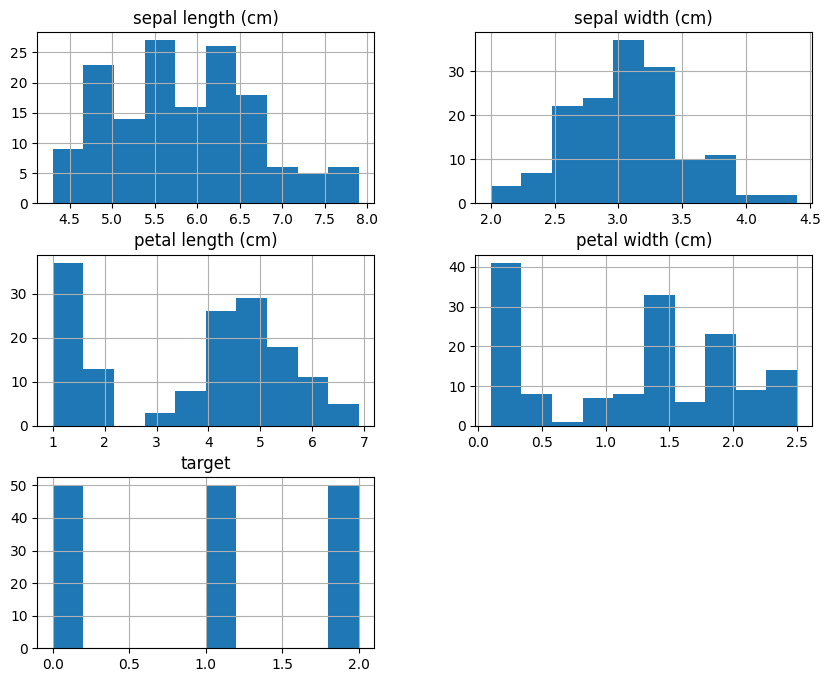

In [14]:
df.hist(figsize=(10,8))
#petal features are highly informative for classification.
#sepal features are less discriminative .
#Dataset is balanced

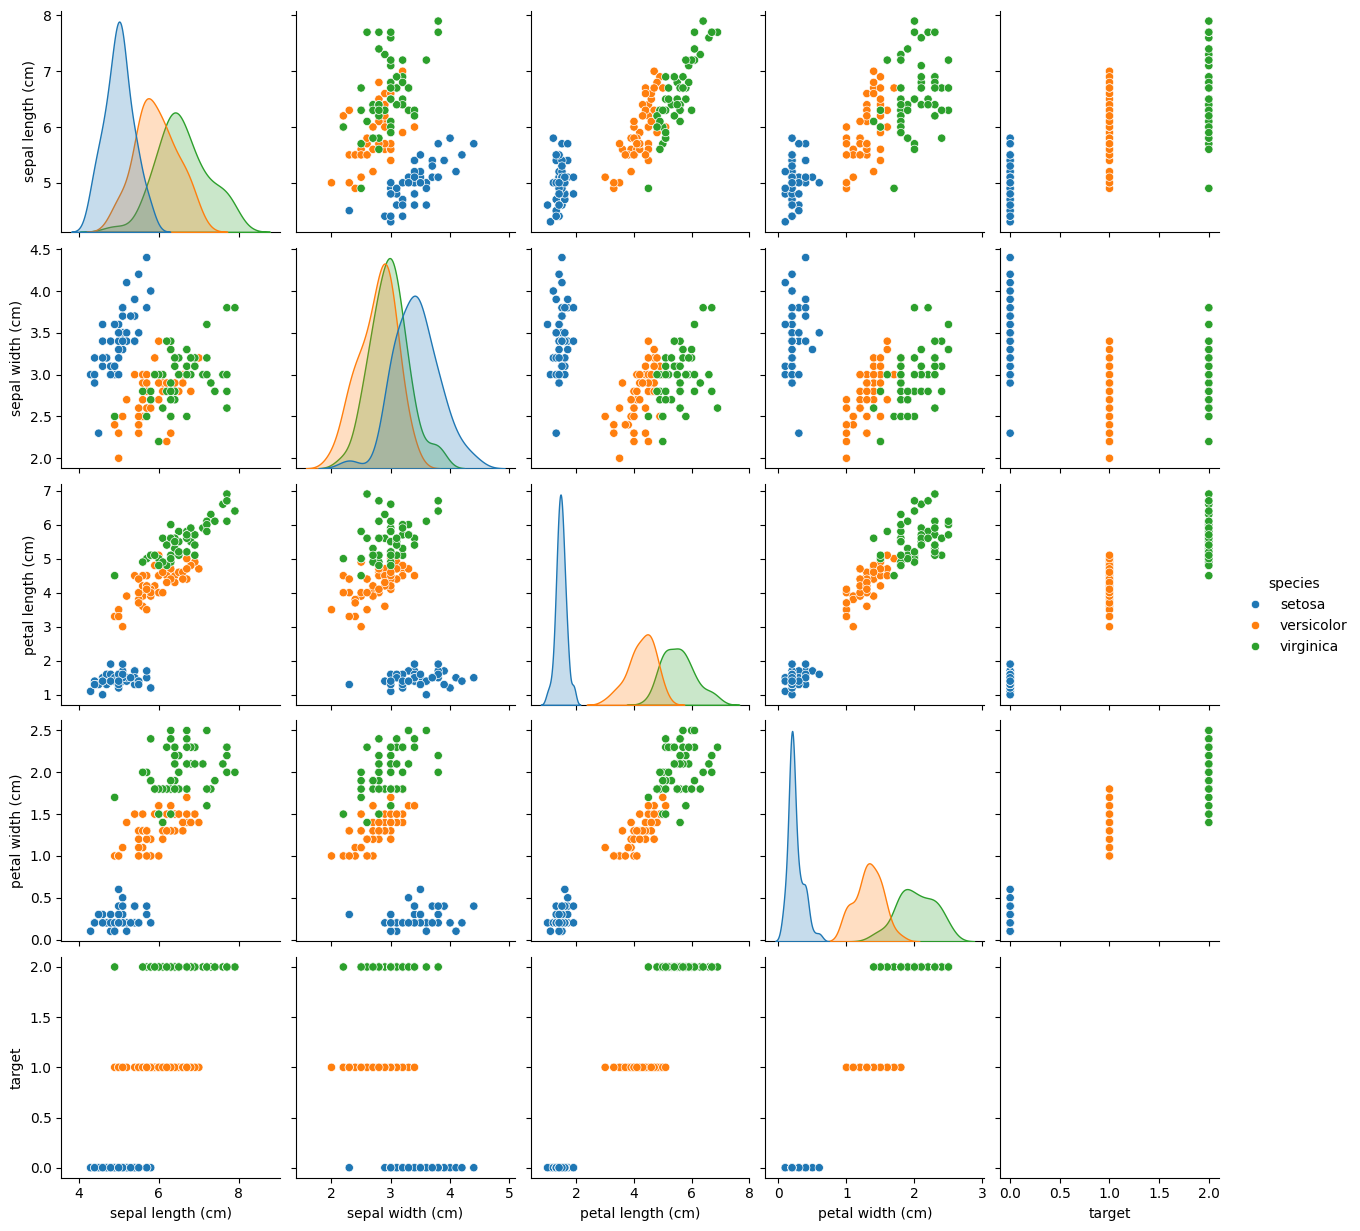

In [15]:
import seaborn as sns
sns.pairplot(df,hue='species')
#setosa is clearly separable from other classes
#petal features provide strong separation between classes.
#sepal features are less effective for classification.

<Axes: xlabel='species', ylabel='petal length (cm)'>

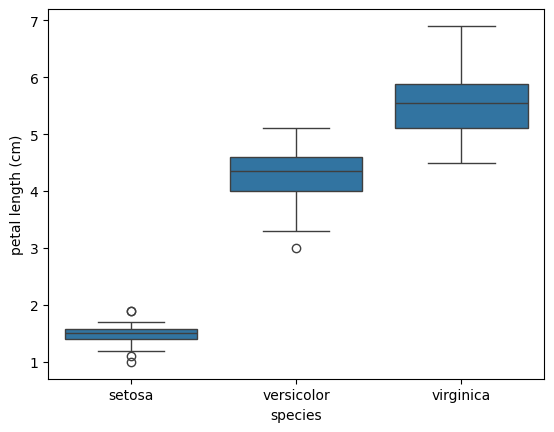

In [ ]:
sns.boxplot(x='species', y = 'petal length (cm)' , data = df)
#petal length clearly separates the three classes without any overlap.

<Axes: >

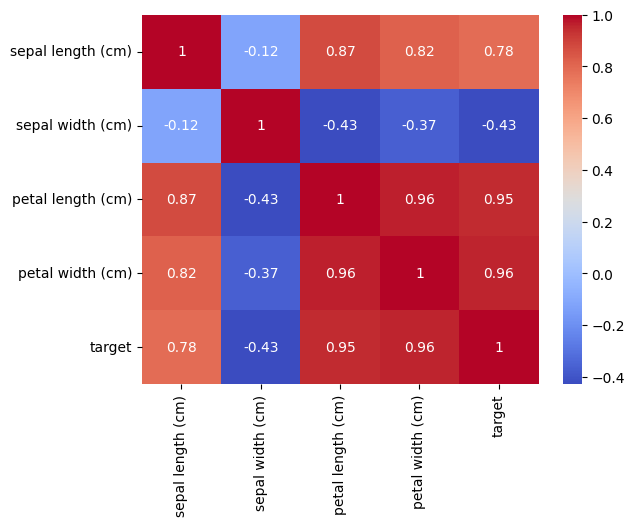

In [ ]:
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap='coolwarm')
#petal features have the strongest correlation with target
#sepal width has weak correlation and may be less useful.
#petal length and width are highly correlated

In [32]:
df['petal_area'] = df['petal length (cm)'] * df['petal width (cm)']
df['sepal_area'] = df['sepal length (cm)'] * df['sepal width (cm)']

In [33]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species', 'petal_area', 'sepal_area'],
      dtype='object')

In [34]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,petal_area,sepal_area
0,5.1,3.5,1.4,0.2,0,setosa,0.28,17.85
1,4.9,3.0,1.4,0.2,0,setosa,0.28,14.70
2,4.7,3.2,1.3,0.2,0,setosa,0.26,15.04
3,4.6,3.1,1.5,0.2,0,setosa,0.30,14.26
4,5.0,3.6,1.4,0.2,0,setosa,0.28,18.00


In [37]:
X = df[['petal length (cm)', 'petal width (cm)', 'petal_area']]
y = df['target']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
cross validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

scores = cross_val_score(model, X, y, cv=5)

print("Scores ", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())
#Cross-validation was applied to evaluate model stability and ensure consistent performance across different data splits.

Scores  [0.96666667 0.96666667 0.93333333 0.9        1.        ]
Mean Accuracy: 0.9533333333333334
Std: 0.03399346342395189


Grid search

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=200),
                    param_grid,
                    cv=5)

grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 1, 'solver': 'liblinear'}
Best Score: 0.9666666666666668


Model

In [47]:
from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(C=1, solver='lbfgs', max_iter=200)
final_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [48]:
y_pred = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
#Although the test accuracy reached 100%, cross-validation revealed a slightly lower average score, 
# indicating that the model may not generalize perfectly to unseen data.

Accuracy: 1.0


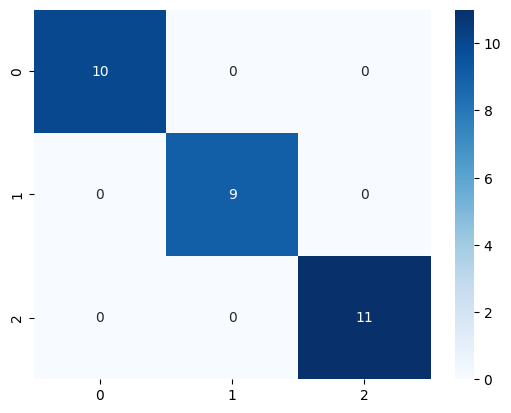

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()

The confusion matrix shows that all samples were correctly classified with no misclassifications. Each class was perfectly predicted, indicating excellent model performance on the test set.

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Decision Tree
cross validation

In [53]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
scores_dt = cross_val_score(dt, X_train, y_train, cv=5)

print("CV Scores:", scores_dt)
print("CV Mean:", scores_dt.mean())

CV Scores: [1.         0.91666667 0.83333333 0.95833333 1.        ]
CV Mean: 0.9416666666666668


Grid search

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_dt.fit(X_train, y_train)
print("Best Params:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Params: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9666666666666668


Model

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

final_dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

final_dt.fit(X_train, y_train)
y_pred_dt = final_dt.predict(X_test)
print("Final Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Final Decision Tree Accuracy: 0.9666666666666667


compare between logistic regression and decision tree

In [58]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Logistic: 1.0
Decision Tree: 0.9666666666666667


Confussion matrix

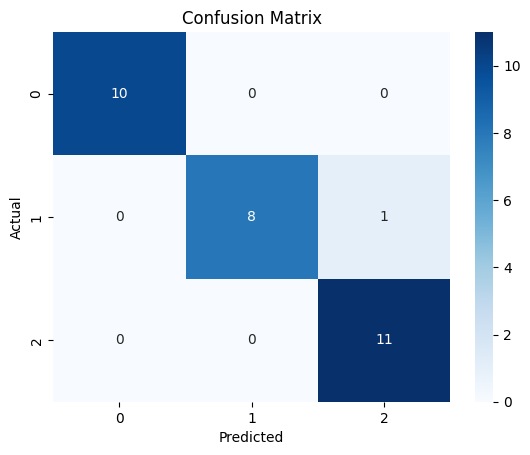

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

A minor misclassification occurred between Versicolor and Virginica, likely due to the similarity and overlap in their feature distributions. This suggests that these two classes are harder to separate compared to Setosa.

In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
pl = float(input("Enter petal length: "))
pw = float(input("Enter petal width: "))

# feature engineering
pa = pl * pw

sample = [[pl, pw, pa]]
sample = scaler.transform(sample)

# prediction
prediction = final_model.predict(sample)

labels = ['setosa', 'versicolor', 'virginica']

print("Predicted species:", labels[prediction[0]])

Predicted species: setosa
